# This notebook generates all the figures required for the report under both MIAS and DDSM datasets

**Note**: Figures 2, 11, 12, and 22 depend on real per-image data (raw crops, real texture maps, or
candidate crop/mask pairs) that either wasn't persisted to Drive or requires re-reading source
images not staged for this figures notebook. They are not regenerated here.

In [1]:
import os, json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    FIG_OUT = '/content/drive/MyDrive/grc_report_figures'
except Exception:
    FIG_OUT = './grc_report_figures'
os.makedirs(FIG_OUT, exist_ok=True)
print('Figures will be written to:', FIG_OUT)

PALETTE = {
    'blue'   : '#0072B2',   # MIAS / primary
    'orange' : '#E69F00',   # CBIS-DDSM / secondary
    'green'  : '#009E73',   # positive / after
    'verm'   : '#D55E00',   # emphasis / warning
    'sky'    : '#56B4E9',
    'purple' : '#CC79A7',
    'grey'   : '#8C8C8C',
    'dark'   : '#333333',
}
CLASS_COL = {'CIRC': '#0072B2', 'SPIC': '#D55E00',
             'MISC': '#009E73', 'NORM': '#8C8C8C'}
MIAS_COL, DDSM_COL = PALETTE['blue'], PALETTE['orange']

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'semibold',
    'axes.labelsize'   : 9.5,
    'xtick.labelsize'  : 8.5,
    'ytick.labelsize'  : 8.5,
    'legend.fontsize'  : 8,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size' : 3,
    'ytick.major.size' : 3,
    'axes.grid'        : True,
    'grid.alpha'       : 0.22,
    'grid.linestyle'   : ':',
    'grid.linewidth'   : 0.7,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'legend.frameon'   : True,
    'legend.framealpha': 0.92,
    'legend.edgecolor' : '#CCCCCC',
    'legend.borderpad' : 0.5,
    'figure.facecolor' : 'white',
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

def save(fig, name):
    # Save a figure as 300 dpi PNG plus vector PDF
    for ext in ('png', 'pdf'):
        fig.savefig(os.path.join(FIG_OUT, f'{name}.{ext}'))
    print(f'  saved {name}.png / .pdf')

def barlabel(ax, bars, fmt='{:.3f}', dy=2, size=7.2, colour=None):
    """Small value label above each bar."""
    for b in bars:
        h = b.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h), (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, dy), textcoords='offset points',
                    ha='center', va='bottom', fontsize=size,
                    color=colour or PALETTE['dark'])

MIAS_K       = [6, 8, 10]
MIAS_K_SCORE = [0.0905, 0.1098, 0.1176]

MIAS_UTIL_BEFORE = [31.56, 68.44, 0, 0, 0, 0, 0, 0]
MIAS_UTIL_AFTER  = [12.5773, 0.4764, 0.8734, 7.0470, 3.1006,
                    19.4067, 17.8292, 5.1592, 15.0463, 18.4838]

MIAS_MATCH = {
    'CIRC': (2, 10, 0.186247, 0.165106),
    'SPIC': (1, 10, 0.129732, 0.201295),
    'MISC': (1, 10, 0.072006, 0.208915),
    'NORM': (2, 10, 0.185302, 0.150746),
}

MIAS_CLASS = {
    'CIRC': (22, 0.8416, 0.0540, 0.7464, 0.9704, 15.5562),
    'SPIC': (19, 0.8099, 0.0526, 0.7019, 0.9749, 17.6315),
    'MISC': (14, 0.8181, 0.0539, 0.7062, 0.9924, 14.5282),
    'NORM': (50, np.nan, np.nan, np.nan, 1.0000, np.nan),
}

MIAS_TISSUE = {
    'D (dense)'          : (12, 0.8408, 0.0303, 0.7378, 0.9896, 16.5671),
    'F (fatty)'          : (23, 0.8324, 0.0527, 0.7340, 0.9796, 14.3071),
    'G (fatty-glandular)': (20, 0.8061, 0.0638, 0.6954, 0.9681, 17.6380),
}

MIAS_ABL = {
    'baseline_3x3_manual'  : (0.8072, 0.6941, 0.9832, 15.7766, 0.1199),
    'mod2_5x5_single_scale': (0.8114, 0.7029, 0.9833, 16.5056, 0.1185),
    'mod1234_no_hybrid'    : (0.8110, 0.7026, 0.9833, 16.4898, 0.1184),
    'full_method'          : (0.8142, 0.7078, 0.9837, 16.3079, 0.1517),
}

DDSM_K       = [6, 8, 10, 12, 14, 16]
DDSM_K_SCORE = [0.0772, 0.0891, 0.0938, 0.0892, 0.0937, 0.0957]

DDSM_INTENS = {
    'CIRC': (0.5808, 0.5509),
    'SPIC': (0.6039, 0.5782),
    'MISC': (0.5810, 0.5542),
}

DDSM_DIM_MASS = [0.0625, 0.0626, 0.0633, 0.0621, 0.0631, 0.0634, 0.0626, 0.0631,
                 0.0619, 0.0621, 0.0627, 0.0619, 0.0634, 0.0615, 0.0621, 0.0616,
                 0.6109, 0.6097, 0.6085]
DDSM_DIM_BG   = [0.0620, 0.0624, 0.0623, 0.0622, 0.0621, 0.0628, 0.0628, 0.0632,
                 0.0619, 0.0620, 0.0632, 0.0630, 0.0632, 0.0622, 0.0623, 0.0625,
                 0.5855, 0.5855, 0.5853]
DDSM_DIM_NAMES = [f'T{i}' for i in range(16)] + ['Int w=5', 'Int w=9', 'Int w=15']

DDSM_STAGES = [
    ('Original\n(majority collapse)',      0.6330, 'invalid'),
    ('Balanced +\nclass_weight',           0.5127, 'real'),
    ('Nearest-centroid\nbaseline',         0.4905, 'baseline'),
    ('After crop\ntightening',             0.5110, 'baseline'),
    ('+ intensity\n(w=7, 17-dim)',         0.5449, 'real'),
    ('XGBoost\n(17-dim)',                  0.5370, 'alt'),
    ('+ multi-scale int.\n(w=5/9/15, 19-dim)', 0.5593, 'final'),
    ('XGBoost\n(19-dim)',                  0.5321, 'alt'),
]

DDSM_IMPORT = {
    'T0': 0.0335, 'T1': 0.0473, 'T2': 0.0513, 'T3': 0.0447, 'T4': 0.0417,
    'T5': 0.0448, 'T6': 0.0491, 'T7': 0.0455, 'T8': 0.0533, 'T9': 0.0365,
    'T10': 0.0405, 'T11': 0.0563, 'T12': 0.0441, 'T13': 0.0493, 'T14': 0.0512,
    'T15': 0.0545,
    'Intensity (w=5)': 0.0581, 'Intensity (w=9)': 0.0526, 'Intensity (w=15)': 0.1457,
}

DDSM_CLASS = {
    'CIRC': (177, 0.6736, 0.1555, 0.8686, 0.9853, 3.2775),
    'SPIC': (180, 0.7615, 0.1518, 0.8347, 0.9877, 4.1928),
    'MISC': (180, 0.7146, 0.1536, 0.8455, 0.9866, 3.8574),
}

DDSM_ABL = {
    'baseline_3x3_manual'  : (0.7048, 0.8834, 0.9849, 3.5095, 0.0301),
    'mod2_5x5_single_scale': (0.6692, 0.8401, 0.9853, 3.6883, 0.0306),
    'mod1234_no_hybrid'    : (0.6681, 0.8398, 0.9853, 3.6795, 0.0307),
    'full_method'          : (0.6703, 0.8493, 0.9847, 3.6537, 0.0843),
}

ARM_SHORT = {
    'baseline_3x3_manual'  : 'baseline\n3x3 manual',
    'mod2_5x5_single_scale': 'mod 2\n5x5 single',
    'mod1234_no_hybrid'    : 'mod 1-4\nno hybrid',
    'full_method'          : 'full\nmethod',
}

print('Data loaded. Ready to generate figures.')

Mounted at /content/drive
Figures will be written to: /content/drive/MyDrive/grc_report_figures
Data loaded. Ready to generate figures.


  saved fig01_architecture.png / .pdf


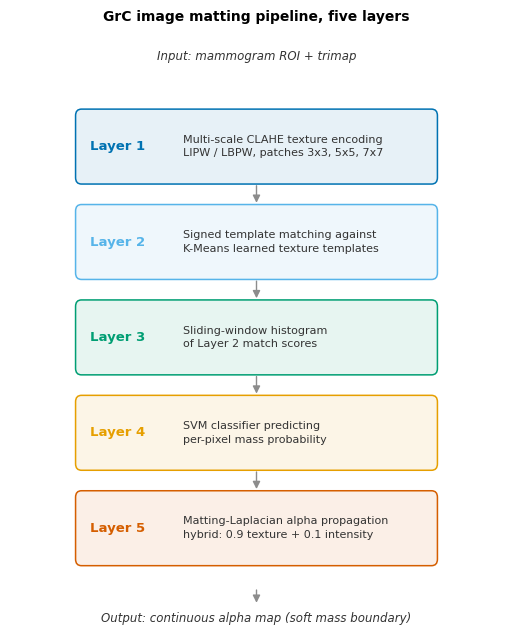

In [2]:
# Figure 1 - Five-layer GrC architecture
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

LAYERS = [
    ('Layer 1', 'Multi-scale CLAHE texture encoding\nLIPW / LBPW, patches 3x3, 5x5, 7x7', PALETTE['blue']),
    ('Layer 2', 'Signed template matching against\nK-Means learned texture templates',    PALETTE['sky']),
    ('Layer 3', 'Sliding-window histogram\nof Layer 2 match scores',                      PALETTE['green']),
    ('Layer 4', 'SVM classifier predicting\nper-pixel mass probability',                  PALETTE['orange']),
    ('Layer 5', 'Matting-Laplacian alpha propagation\nhybrid: 0.9 texture + 0.1 intensity', PALETTE['verm']),
]

fig, ax = plt.subplots(figsize=(5.2, 6.4))
ax.set_xlim(0, 10); ax.set_ylim(0, 10.6); ax.axis('off')

y, h, gap = 9.15, 1.35, 0.42
box_x, box_w = 1.35, 7.3

ax.text(5, 10.15, 'Input: mammogram ROI + trimap', ha='center', va='center',
        fontsize=8.5, style='italic', color=PALETTE['dark'])

for i, (name, desc, col) in enumerate(LAYERS):
    box = FancyBboxPatch((box_x, y - h), box_w, h,
                         boxstyle='round,pad=0.02,rounding_size=0.12',
                         linewidth=1.1, edgecolor=col, facecolor=col + '18')
    ax.add_patch(box)
    ax.text(box_x + 0.28, y - h / 2, name, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=col)
    ax.text(box_x + 2.15, y - h / 2, desc, ha='left', va='center',
            fontsize=8, color=PALETTE['dark'], linespacing=1.45)
    if i < len(LAYERS) - 1:
        ax.add_patch(FancyArrowPatch((5, y - h), (5, y - h - gap),
                                     arrowstyle='-|>', mutation_scale=11,
                                     linewidth=1.0, color=PALETTE['grey']))
    y -= (h + gap)

ax.add_patch(FancyArrowPatch((5, y), (5, y - 0.34), arrowstyle='-|>',
                             mutation_scale=11, linewidth=1.0, color=PALETTE['grey']))
ax.text(5, y - 0.58, 'Output: continuous alpha map (soft mass boundary)',
        ha='center', va='center', fontsize=8.5, style='italic', color=PALETTE['dark'])

ax.set_title('GrC image matting pipeline, five layers', pad=8)
fig.tight_layout()
save(fig, 'fig01_architecture')
plt.show()

  saved fig02_mias_k_selection.png / .pdf


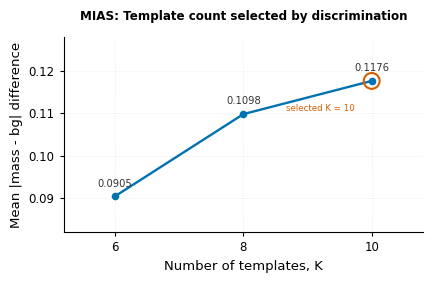

In [3]:
# Figure 2 - MIAS K-selection: mean absolute mass-vs-background difference against K
fig, ax = plt.subplots(figsize=(4.4, 2.9))

ax.plot(MIAS_K, MIAS_K_SCORE, 'o-', color=MIAS_COL, linewidth=1.7,
        markersize=5.5, markeredgewidth=0, zorder=3)
best = int(np.argmax(MIAS_K_SCORE))
ax.scatter([MIAS_K[best]], [MIAS_K_SCORE[best]], s=130, facecolor='none',
           edgecolor=PALETTE['verm'], linewidth=1.5, zorder=4)
ax.annotate(f'selected K = {MIAS_K[best]}',
            (MIAS_K[best], MIAS_K_SCORE[best]), xytext=(-12, -22),
            textcoords='offset points', ha='right', fontsize=6.2,
            color=PALETTE['verm'])
for k, s in zip(MIAS_K, MIAS_K_SCORE):
    ax.annotate(f'{s:.4f}', (k, s), xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=7.2, color=PALETTE['dark'])

ax.set(xlabel='Number of templates, K', ylabel='Mean |mass - bg| difference')
ax.set_title('MIAS: Template count selected by discrimination', fontsize=8.6, pad=12)
ax.set_xticks(MIAS_K)
ax.set_xlim(5.2, 10.8); ax.set_ylim(0.082, 0.128)
fig.tight_layout()
save(fig, 'fig02_mias_k_selection')
plt.show()

  saved fig03_mias_template_utilisation.png / .pdf


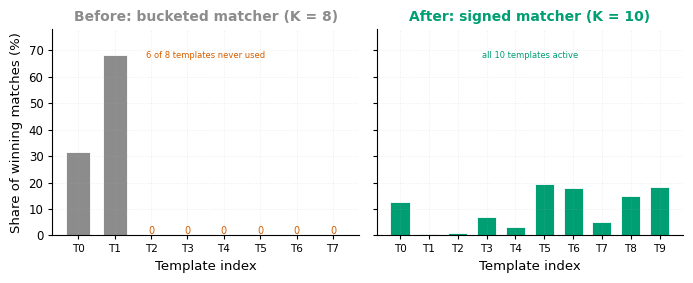

In [4]:
# Figure 3 - MIAS template utilisation before and after the Layer 2 matcher fix
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True)

xb = np.arange(len(MIAS_UTIL_BEFORE))
bars_b = axes[0].bar(xb, MIAS_UTIL_BEFORE, width=0.66, color=PALETTE['grey'],
                     edgecolor='white', linewidth=0.6)
for b, v in zip(bars_b, MIAS_UTIL_BEFORE):
    if v == 0:
        axes[0].annotate('0', (b.get_x() + b.get_width() / 2, 0.6), ha='center',
                         fontsize=7, color=PALETTE['verm'])
axes[0].set_title('Before: bucketed matcher (K = 8)', color=PALETTE['grey'])
axes[0].set_xticks(xb); axes[0].set_xticklabels([f'T{i}' for i in xb], fontsize=7.5)
axes[0].set_ylabel('Share of winning matches (%)')
axes[0].text(0.5, 0.86, '6 of 8 templates never used', transform=axes[0].transAxes,
             ha='center', fontsize=6, color=PALETTE['verm'])

xa = np.arange(len(MIAS_UTIL_AFTER))
axes[1].bar(xa, MIAS_UTIL_AFTER, width=0.66, color=PALETTE['green'],
            edgecolor='white', linewidth=0.6)
axes[1].set_title('After: signed matcher (K = 10)', color=PALETTE['green'])
axes[1].set_xticks(xa); axes[1].set_xticklabels([f'T{i}' for i in xa], fontsize=7.5)
axes[1].text(0.5, 0.86, 'all 10 templates active', transform=axes[1].transAxes,
             ha='center', fontsize=6, color=PALETTE['green'])

for ax in axes:
    ax.set_xlabel('Template index')
    ax.set_ylim(0, 78)
fig.tight_layout()
save(fig, 'fig03_mias_template_utilisation')
plt.show()

  saved fig04_mias_matcher_effect.png / .pdf


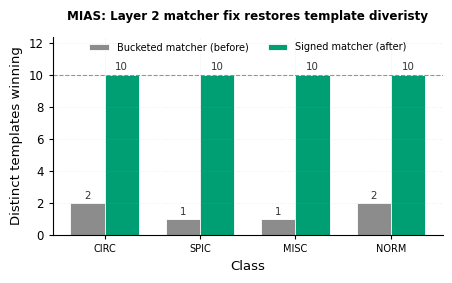

In [5]:
# Figure 4 - MIAS Layer 2 matcher fix: distinct templates winning per class
classes = list(MIAS_MATCH.keys())
old_used = [MIAS_MATCH[c][0] for c in classes]
new_used = [MIAS_MATCH[c][1] for c in classes]
x = np.arange(len(classes)); w = 0.36

fig, ax = plt.subplots(figsize=(4.6, 2.9))
b1 = ax.bar(x - w / 2, old_used, w, label='Bucketed matcher (before)',
            color=PALETTE['grey'], edgecolor='white', linewidth=0.6)
b2 = ax.bar(x + w / 2, new_used, w, label='Signed matcher (after)',
            color=PALETTE['green'], edgecolor='white', linewidth=0.6)
barlabel(ax, b1, fmt='{:.0f}', size=7.4)
barlabel(ax, b2, fmt='{:.0f}', size=7.4)

ax.axhline(10, color=PALETTE['dark'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.set(xlabel='Class', ylabel='Distinct templates winning')
ax.set_title('MIAS: Layer 2 matcher fix restores template diveristy', fontsize=8.6, pad=12)
ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=7)
ax.set_ylim(0, 12.4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=7, frameon=False)
fig.tight_layout()
save(fig, 'fig04_mias_matcher_effect')
plt.show()

  saved fig05_mias_per_class.png / .pdf


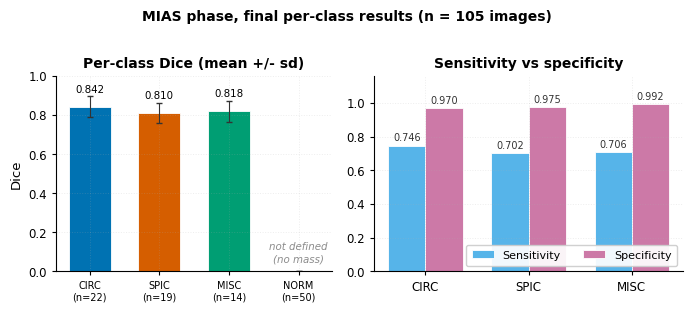

In [6]:
# Figure 5 - MIAS final per-class results: Dice with sensitivity and specificity
order = ['CIRC', 'SPIC', 'MISC', 'NORM']
dice  = [MIAS_CLASS[c][1] for c in order]
dstd  = [MIAS_CLASS[c][2] for c in order]
sens  = [MIAS_CLASS[c][3] for c in order]
spec  = [MIAS_CLASS[c][4] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0),
                         gridspec_kw={'width_ratios': [1, 1.12]})

# left: Dice with std error bars, NORM shown as not applicable
xs = np.arange(len(order))
bars = axes[0].bar(xs, [0 if np.isnan(d) else d for d in dice], width=0.6,
                   color=[CLASS_COL[c] for c in order],
                   edgecolor='white', linewidth=0.6,
                   yerr=[0 if np.isnan(s) else s for s in dstd],
                   error_kw=dict(ecolor=PALETTE['dark'], elinewidth=0.8, capsize=2.5))
for i, d in enumerate(dice):
    if np.isnan(d):
        bars[i].set_height(0)
        axes[0].annotate('not defined\n(no mass)', (i, 0.04), ha='center',
                         va='bottom', fontsize=7.4, color=PALETTE['grey'],
                         style='italic')
    else:
        axes[0].annotate(f'{d:.3f}', (i, d + dstd[i]), xytext=(0, 3),
                         textcoords='offset points', ha='center', fontsize=7.4)
axes[0].set(ylabel='Dice', title='Per-class Dice (mean +/- sd)')
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f'{c}\n(n={MIAS_CLASS[c][0]})' for c in order], fontsize=7)
axes[0].set_ylim(0, 1.0)

# right: sensitivity vs specificity
w = 0.36
m = [c for c in order if not np.isnan(MIAS_CLASS[c][1])]
xm = np.arange(len(m))
b1 = axes[1].bar(xm - w / 2, [MIAS_CLASS[c][3] for c in m], w,
                 label='Sensitivity', color=PALETTE['sky'],
                 edgecolor='white', linewidth=0.6)
b2 = axes[1].bar(xm + w / 2, [MIAS_CLASS[c][4] for c in m], w,
                 label='Specificity', color=PALETTE['purple'],
                 edgecolor='white', linewidth=0.6)
barlabel(axes[1], b1, size=7); barlabel(axes[1], b2, size=7)
axes[1].set(title='Sensitivity vs specificity')
axes[1].set_xticks(xm); axes[1].set_xticklabels(m)
axes[1].set_ylim(0, 1.16)
axes[1].legend(loc='lower right', ncol=2)

fig.suptitle('MIAS phase, final per-class results (n = 105 images)',
             fontsize=10, fontweight='semibold', y=1.02)
fig.tight_layout()
save(fig, 'fig05_mias_per_class')
plt.show()

  saved fig06_mias_per_tissue.png / .pdf


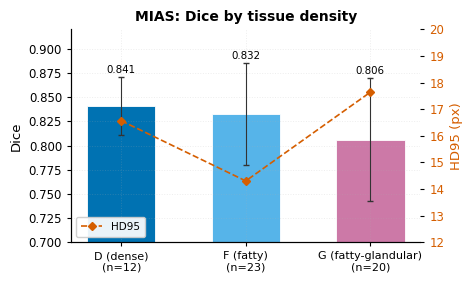

In [7]:
# Figure 6 - MIAS Dice by tissue density, with HD95 overlaid
tis   = list(MIAS_TISSUE.keys())
tdice = [MIAS_TISSUE[t][1] for t in tis]
tstd  = [MIAS_TISSUE[t][2] for t in tis]
thd   = [MIAS_TISSUE[t][5] for t in tis]
x = np.arange(len(tis))

fig, ax = plt.subplots(figsize=(4.8, 2.9))
bars = ax.bar(x, tdice, width=0.55, color=[PALETTE['blue'], PALETTE['sky'],
                                           PALETTE['purple']],
              edgecolor='white', linewidth=0.6, yerr=tstd,
              error_kw=dict(ecolor=PALETTE['dark'], elinewidth=0.8, capsize=2.5))
for b, d, s in zip(bars, tdice, tstd):
    ax.annotate(f'{d:.3f}', (b.get_x() + b.get_width() / 2, d + s),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7.4)

ax.set(ylabel='Dice', title='MIAS: Dice by tissue density')
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={MIAS_TISSUE[t][0]})' for t in tis], fontsize=8)
ax.set_ylim(0.70, 0.92)

ax2 = ax.twinx()
ax2.plot(x, thd, 'D--', color=PALETTE['verm'], linewidth=1.2, markersize=4.5,
         label='HD95')
ax2.set_ylabel('HD95 (px)', color=PALETTE['verm'])
ax2.tick_params(axis='y', labelcolor=PALETTE['verm'])
ax2.set_ylim(12, 20); ax2.grid(False)
ax2.legend(loc='lower left', fontsize=7.5)

fig.tight_layout()
save(fig, 'fig06_mias_per_tissue')
plt.show()

  saved fig07_mias_ablation.png / .pdf


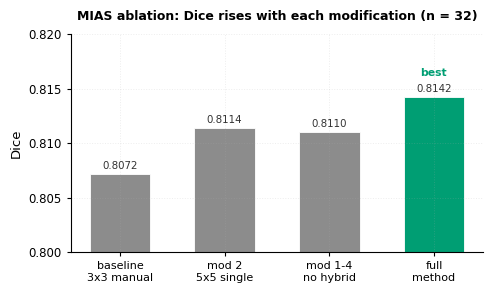

In [8]:
# Figure 7 (verify against report PDF) - MIAS ablation: Dice by arm
arms  = list(MIAS_ABL.keys())
dice  = [MIAS_ABL[a][0] for a in arms]
x = np.arange(len(arms))
best = int(np.argmax(dice))
cols = [PALETTE['grey']] * len(arms); cols[best] = PALETTE['green']

fig, ax = plt.subplots(figsize=(5.0, 3.0))
bars = ax.bar(x, dice, width=0.58, color=cols, edgecolor='white', linewidth=0.6)
barlabel(ax, bars, fmt='{:.4f}', size=7.4)
ax.annotate('best', (best, dice[best]), xytext=(0, 15),
            textcoords='offset points', ha='center', fontsize=7.8,
            color=PALETTE['green'], fontweight='bold')

ax.set(ylabel='Dice')
ax.set_title('MIAS ablation: Dice rises with each modification (n = 32)', fontsize=9, pad=10)
ax.set_xticks(x); ax.set_xticklabels([ARM_SHORT[a] for a in arms], fontsize=8)
ax.set_ylim(0.800, 0.820)
ax.yaxis.set_major_locator(MultipleLocator(0.005))
fig.tight_layout()
save(fig, 'fig07_mias_ablation')
plt.show()

  saved fig08_ddsm_k_selection.png / .pdf


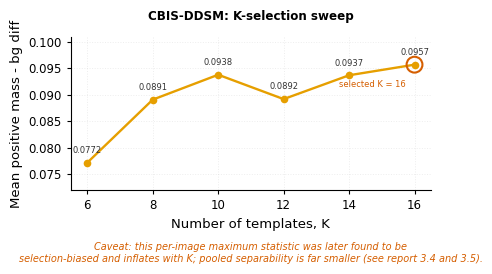

In [9]:
# Figure 8 - CBIS-DDSM K-selection sweep, with the selection-bias caveat
fig, ax = plt.subplots(figsize=(4.9, 3.1))

ax.plot(DDSM_K, DDSM_K_SCORE, 'o-', color=DDSM_COL, linewidth=1.7,
        markersize=5.5, markeredgewidth=0, zorder=3)
best = int(np.argmax(DDSM_K_SCORE))
ax.scatter([DDSM_K[best]], [DDSM_K_SCORE[best]], s=130, facecolor='none',
           edgecolor=PALETTE['verm'], linewidth=1.5, zorder=4)
ax.annotate(f'selected K = {DDSM_K[best]}', (DDSM_K[best], DDSM_K_SCORE[best]),
            xytext=(-6, -16), textcoords='offset points', ha='right',
            fontsize=6, color=PALETTE['verm'])
for k, s in zip(DDSM_K, DDSM_K_SCORE):
    ax.annotate(f'{s:.4f}', (k, s), xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=6, color=PALETTE['dark'])

ax.text(0.5, -0.34,
        'Caveat: this per-image maximum statistic was later found to be\n'
        'selection-biased and inflates with K; pooled separability is far smaller '
        '(see report 3.4 and 3.5).',
        transform=ax.transAxes, ha='center', va='top', fontsize=7,
        style='italic', color=PALETTE['verm'])

ax.set(xlabel='Number of templates, K', ylabel='Mean positive mass - bg diff')
ax.set_title('CBIS-DDSM: K-selection sweep', fontsize=8.6, pad=12)
ax.set_xticks(DDSM_K)
ax.set_ylim(0.072, 0.101)
fig.tight_layout()
save(fig, 'fig08_ddsm_k_selection')
plt.show()

  saved fig09_ddsm_intensity_diagnostic.png / .pdf


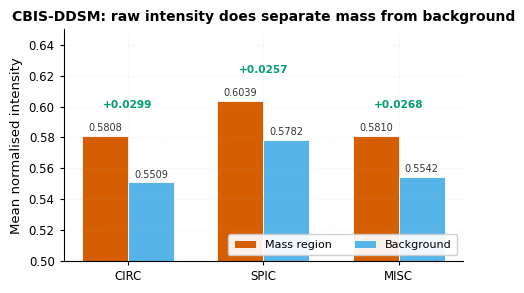

In [10]:
# Figure 9 - CBIS-DDSM per-class raw intensity diagnostic
cls  = list(DDSM_INTENS.keys())
mass = [DDSM_INTENS[c][0] for c in cls]
bg   = [DDSM_INTENS[c][1] for c in cls]
diff = [m - b for m, b in zip(mass, bg)]
x = np.arange(len(cls)); w = 0.34

fig, ax = plt.subplots(figsize=(4.8, 3.0))
b1 = ax.bar(x - w / 2, mass, w, label='Mass region', color=PALETTE['verm'],
            edgecolor='white', linewidth=0.6)
b2 = ax.bar(x + w / 2, bg, w, label='Background', color=PALETTE['sky'],
            edgecolor='white', linewidth=0.6)
barlabel(ax, b1, fmt='{:.4f}', size=7); barlabel(ax, b2, fmt='{:.4f}', size=7)

for i, d in enumerate(diff):
    ax.annotate(f'+{d:.4f}', (i, max(mass[i], bg[i]) + 0.018), ha='center',
                fontsize=7.6, color=PALETTE['green'], fontweight='bold')

ax.set(ylabel='Mean normalised intensity',
       title='CBIS-DDSM: raw intensity does separate mass from background')
ax.set_xticks(x); ax.set_xticklabels(cls)
ax.set_ylim(0.50, 0.65)
ax.legend(loc='lower right', ncol=2)
fig.tight_layout()
save(fig, 'fig09_ddsm_intensity_diagnostic')
plt.show()

  saved fig10_ddsm_dimension_separability.png / .pdf


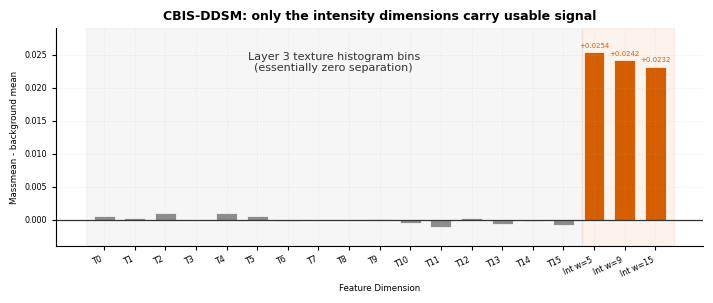

In [11]:
# Figure 10 - CBIS-DDSM per-dimension separability, texture vs intensity
diffs = [m - b for m, b in zip(DDSM_DIM_MASS, DDSM_DIM_BG)]
x = np.arange(len(diffs))
cols = [PALETTE['grey']] * 16 + [PALETTE['verm']] * 3

fig, ax = plt.subplots(figsize=(7.2, 3.1))
ax.bar(x, diffs, width=0.68, color=cols, edgecolor='white', linewidth=0.5)
ax.axhline(0, color=PALETTE['dark'], linewidth=0.9)

ax.axvspan(-0.6, 15.6, color=PALETTE['grey'], alpha=0.07, zorder=0)
ax.axvspan(15.6, 18.6, color=PALETTE['verm'], alpha=0.07, zorder=0)
ax.text(7.5, 0.0225, 'Layer 3 texture histogram bins\n(essentially zero separation)',
        ha='center', fontsize=8, color=PALETTE['dark'])

offsets=[3, 10, 17]
for i in (16, 17, 18):
    ax.annotate(f'+{diffs[i]:.4f}', (i, diffs[i]), xytext=(0, 3),
                textcoords='offset points', ha='center', fontsize=5,
                color=PALETTE['verm'])

ax.set_title('CBIS-DDSM: only the intensity dimensions carry usable signal', fontsize=9)
ax.set_xlabel('Feature Dimension', fontsize=6.2)
ax.set_ylabel('Massmean - background mean', fontsize=6.2)
ax.set_xticks(x); ax.set_xticklabels(DDSM_DIM_NAMES, fontsize=6, rotation=25, ha='right')
ax.set_ylim(-0.004, 0.029)
ax.tick_params(axis='y', labelsize=5.8)
ax.tick_params(axis='x', labelsize=5.8)
fig.tight_layout()
save(fig, 'fig10_ddsm_dimension_separability')
plt.show()

  saved fig11_ddsm_svm_journey.png / .pdf


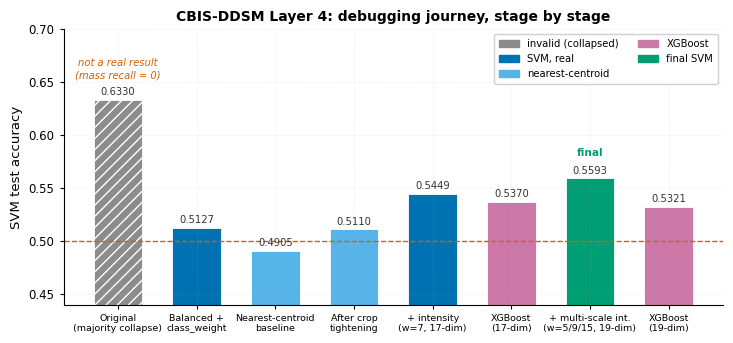

In [12]:
# Figure 11 - CBIS-DDSM Layer 4 debugging journey, stage by stage
labels = [s[0] for s in DDSM_STAGES]
accs   = [s[1] for s in DDSM_STAGES]
kinds  = [s[2] for s in DDSM_STAGES]
KIND_COL = {'invalid': PALETTE['grey'], 'real': PALETTE['blue'],
            'baseline': PALETTE['sky'], 'alt': PALETTE['purple'],
            'final': PALETTE['green']}
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7.4, 3.5))
bars = ax.bar(x, accs, width=0.62, color=[KIND_COL[k] for k in kinds],
              edgecolor='white', linewidth=0.6)
barlabel(ax, bars, fmt='{:.4f}', size=7.2)

ax.axhline(0.5, color=PALETTE['verm'], linestyle='--', linewidth=1)

bars[0].set_hatch('///'); bars[0].set_edgecolor('white')
ax.annotate('not a real result\n(mass recall = 0)', (0, accs[0]), xytext=(0, 16),
            textcoords='offset points', ha='center', fontsize=7.2,
            color=PALETTE['verm'], style='italic')
ax.annotate('final', (6, accs[6]), xytext=(0, 16), textcoords='offset points',
            ha='center', fontsize=7.6, color=PALETTE['green'], fontweight='bold')

ax.set(ylabel='SVM test accuracy',
       title='CBIS-DDSM Layer 4: debugging journey, stage by stage')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=6.8)
ax.set_ylim(0.44, 0.70)

handles = [plt.Rectangle((0, 0), 1, 1, color=KIND_COL[k]) for k in
           ['invalid', 'real', 'baseline', 'alt', 'final']]
ax.legend(handles, ['invalid (collapsed)', 'SVM, real', 'nearest-centroid',
                    'XGBoost', 'final SVM'],
          loc='upper right', ncol=2, fontsize=7.2)
fig.tight_layout()
save(fig, 'fig11_ddsm_svm_journey')
plt.show()

  saved fig12_ddsm_feature_importance.png / .pdf


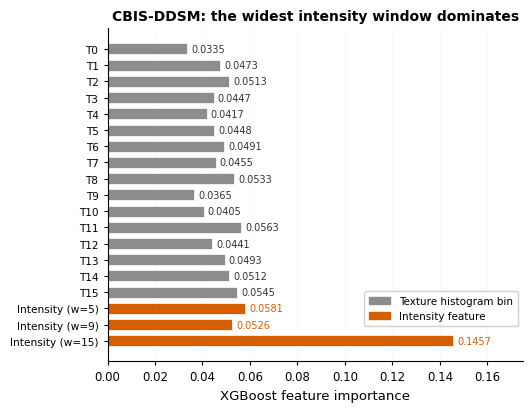

In [13]:
# Figure 12 - CBIS-DDSM XGBoost feature importance, widest intensity window dominates
names = list(DDSM_IMPORT.keys())
vals  = [DDSM_IMPORT[n] for n in names]
is_int = ['Intensity' in n for n in names]
cols  = [PALETTE['verm'] if i else PALETTE['grey'] for i in is_int]
y = np.arange(len(names))[::-1]     # horizontal layout keeps labels readable

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.barh(y, vals, height=0.68, color=cols, edgecolor='white', linewidth=0.5)
for yy, v, i in zip(y, vals, is_int):
    ax.annotate(f'{v:.4f}', (v, yy), xytext=(3, 0), textcoords='offset points',
                va='center', fontsize=7,
                color=PALETTE['verm'] if i else PALETTE['dark'])

ax.set_yticks(y); ax.set_yticklabels(names, fontsize=7.6)
ax.set(xlabel='XGBoost feature importance',
       title='CBIS-DDSM: the widest intensity window dominates')
ax.set_xlim(0, 0.175)
ax.grid(axis='y', visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE['grey']),
           plt.Rectangle((0, 0), 1, 1, color=PALETTE['verm'])]
ax.legend(handles, ['Texture histogram bin', 'Intensity feature'],
          loc='lower right', fontsize=7.5, bbox_to_anchor=(1.0, 0.09))
fig.tight_layout()
save(fig, 'fig12_ddsm_feature_importance')
plt.show()

  saved fig13_ddsm_per_class.png / .pdf


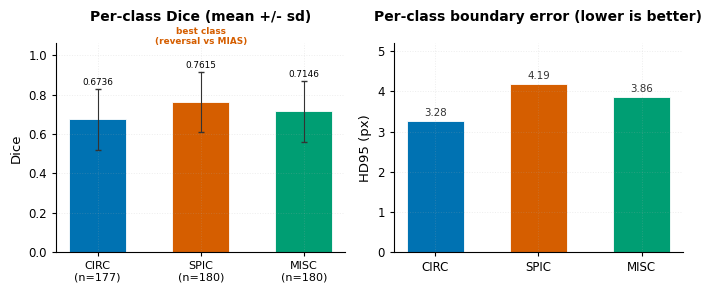

  saved fig14_ddsm_ablation.png / .pdf


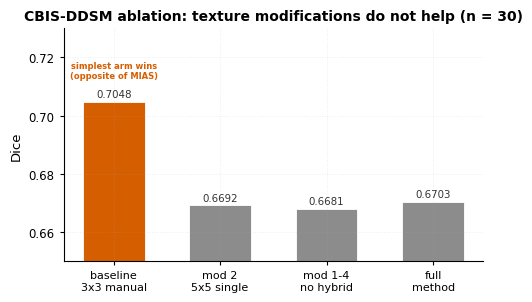

In [14]:
# Figure 13 - CBIS-DDSM final per-class results (Dice + HD95)
# Figure 14 - CBIS-DDSM ablation study: Dice by arm (below, same cell)
order = ['CIRC', 'SPIC', 'MISC']
dice  = [DDSM_CLASS[c][1] for c in order]
dstd  = [DDSM_CLASS[c][2] for c in order]
hd95  = [DDSM_CLASS[c][5] for c in order]
x = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))
bars = axes[0].bar(x, dice, width=0.55, color=[CLASS_COL[c] for c in order],
                   edgecolor='white', linewidth=0.6, yerr=dstd,
                   error_kw=dict(ecolor=PALETTE['dark'], elinewidth=0.8, capsize=2.5))
for b, d, s in zip(bars, dice, dstd):
    axes[0].annotate(f'{d:.4f}', (b.get_x() + b.get_width() / 2, d + s),
                     xytext=(0, 3), textcoords='offset points', ha='center',
                     fontsize=6.4)
best = int(np.argmax(dice))
axes[0].annotate('best class\n(reversal vs MIAS)', (best, dice[best] + dstd[best]),
                 xytext=(0, 20), textcoords='offset points', ha='center',
                 fontsize=6.4, color=PALETTE['verm'], fontweight='bold')
axes[0].set(ylabel='Dice')
axes[0].set_title('Per-class Dice (mean +/- sd)', pad=16)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c}\n(n={DDSM_CLASS[c][0]})' for c in order], fontsize=8)
axes[0].set_ylim(0, 1.06)

hb = axes[1].bar(x, hd95, width=0.55, color=[CLASS_COL[c] for c in order],
                 edgecolor='white', linewidth=0.6)
barlabel(axes[1], hb, fmt='{:.2f}', size=7.4)
axes[1].set(ylabel='HD95 (px)')
axes[1].set_title('Per-class boundary error (lower is better)', pad=16)
axes[1].set_xticks(x); axes[1].set_xticklabels(order)
axes[1].set_ylim(0, 5.2)
fig.tight_layout()
save(fig, 'fig13_ddsm_per_class')
plt.show()

arms = list(DDSM_ABL.keys())
adice = [DDSM_ABL[a][0] for a in arms]
x = np.arange(len(arms))
best = int(np.argmax(adice))
cols = [PALETTE['grey']] * len(arms); cols[best] = PALETTE['verm']

fig, ax = plt.subplots(figsize=(5.0, 3.1))
bars = ax.bar(x, adice, width=0.58, color=cols, edgecolor='white', linewidth=0.6)
barlabel(ax, bars, fmt='{:.4f}', size=7.4)
ax.annotate('simplest arm wins\n(opposite of MIAS)', (best, adice[best]),
            xytext=(0, 17), textcoords='offset points', ha='center',
            fontsize=6, color=PALETTE['verm'], fontweight='bold')

ax.set(ylabel='Dice',
       title='CBIS-DDSM ablation: texture modifications do not help (n = 30)')
ax.set_xticks(x); ax.set_xticklabels([ARM_SHORT[a] for a in arms], fontsize=8)
ax.set_ylim(0.650, 0.730)
ax.yaxis.set_major_locator(MultipleLocator(0.02))
fig.tight_layout()
save(fig, 'fig14_ddsm_ablation')
plt.show()

  saved fig15_cross_dataset_dice.png / .pdf


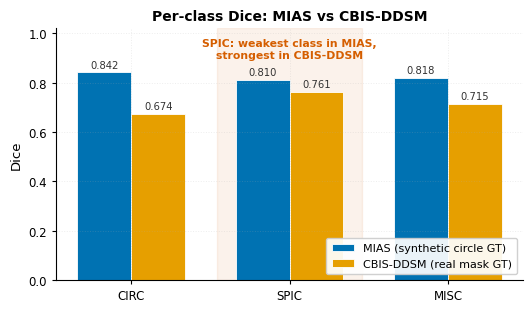

In [15]:
# Figure 15 - Cross-dataset per-class Dice comparison (MIAS vs CBIS-DDSM)
order = ['CIRC', 'SPIC', 'MISC']          # NORM excluded: no CBIS-DDSM equivalent
mias  = [MIAS_CLASS[c][1] for c in order]
ddsm  = [DDSM_CLASS[c][1] for c in order]
x = np.arange(len(order)); w = 0.34

fig, ax = plt.subplots(figsize=(5.4, 3.2))
b1 = ax.bar(x - w / 2, mias, w, label='MIAS (synthetic circle GT)',
            color=MIAS_COL, edgecolor='white', linewidth=0.6)
b2 = ax.bar(x + w / 2, ddsm, w, label='CBIS-DDSM (real mask GT)',
            color=DDSM_COL, edgecolor='white', linewidth=0.6)
barlabel(ax, b1, fmt='{:.3f}', size=7.2)
barlabel(ax, b2, fmt='{:.3f}', size=7.2)

# highlight the SPIC reversal, the key message of this chart
spic = order.index('SPIC')
ax.axvspan(spic - 0.46, spic + 0.46, color=PALETTE['verm'], alpha=0.08, zorder=0)
ax.annotate('SPIC: weakest class in MIAS,\nstrongest in CBIS-DDSM',
            (spic, 0.90), ha='center', fontsize=7.8, color=PALETTE['verm'],
            fontweight='bold')
ax.annotate('', xy=(spic + w / 2, ddsm[spic] + 0.03),
            xytext=(spic - w / 2, mias[spic] + 0.03))

ax.set(ylabel='Dice', title='Per-class Dice: MIAS vs CBIS-DDSM')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right')
fig.tight_layout()
save(fig, 'fig15_cross_dataset_dice')
plt.show()

MIAS sample grid:
  saved fig16_mias_alpha_grid.png / .pdf


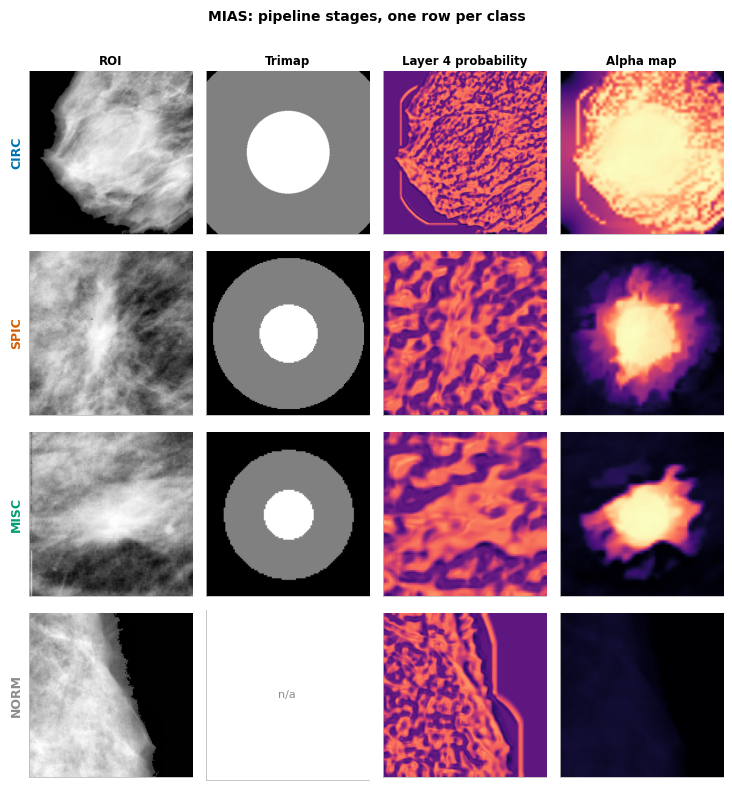

CBIS-DDSM sample grid:
  saved fig17_ddsm_alpha_grid.png / .pdf


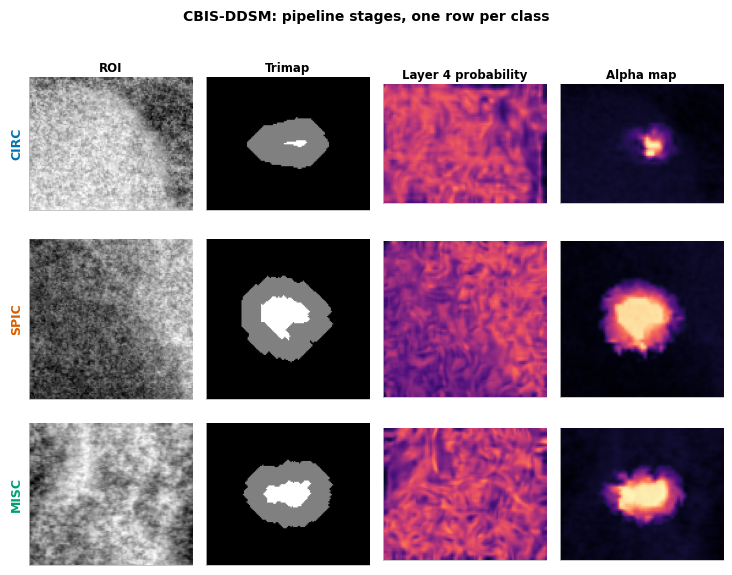

In [16]:
# Figure 16 - MIAS: pipeline stages sample grid (ROI/trimap/prob/alpha), one row per class
# Figure 17 - CBIS-DDSM: pipeline stages sample grid, one row per class (below, same cell)
REGENERATE_SAMPLES = True

MIAS_ROOT = '/content/drive/MyDrive/mias_grc_project'
DDSM_ROOT = '/content/drive/MyDrive/cbis_ddsm_grc_project'

def _load_npz(path):
    return np.load(path) if os.path.exists(path) else None

def sample_grid(root, classes, title, outname, alpha_file='alpha_maps_full.npz'):
    """ROI / trimap / Layer 4 probability / alpha, one row per class."""
    import pandas as pd
    df_path = os.path.join(root, 'results', 'final_df_loaded.csv')
    if not os.path.exists(df_path):
        print(f'  skip {outname}: {df_path} not found'); return
    df = pd.read_csv(df_path)

    rois   = _load_npz(os.path.join(root, 'preprocessed', 'rois.npz'))
    trims  = _load_npz(os.path.join(root, 'trimaps', 'trimaps.npz'))
    probs  = _load_npz(os.path.join(root, 'outputs', 'layer4_prob_maps.npz'))
    alphas = _load_npz(os.path.join(root, 'alpha_maps', alpha_file))
    if rois is None or alphas is None:
        print(f'  skip {outname}: required npz files not found'); return

    picks = []
    for c in classes:
        sub = df[df['class'] == c]
        for _, r in sub.iterrows():
            if str(r['image_id']) in rois.files:
                picks.append((c, str(r['image_id']))); break

    if not picks:
        print(f'  skip {outname}: no matching images'); return

    ncol = 4
    fig, axes = plt.subplots(len(picks), ncol,
                             figsize=(1.85 * ncol, 1.95 * len(picks)))
    axes = np.atleast_2d(axes)
    col_titles = ['ROI', 'Trimap', 'Layer 4 probability', 'Alpha map']

    for r, (cls, iid) in enumerate(picks):
        panels = [
            (rois[iid], 'gray', None),
            (trims[iid] if trims is not None and iid in trims.files else None, 'gray', None),
            (probs[iid] if probs is not None and iid in probs.files else None, 'magma', (0, 1)),
            (alphas[iid] if iid in alphas.files else None, 'magma', (0, 1)),
        ]
        for c, (img, cmap, lim) in enumerate(panels):
            ax = axes[r, c]
            if img is None:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center',
                        fontsize=8, color=PALETTE['grey'], transform=ax.transAxes)
            else:
                kw = dict(vmin=lim[0], vmax=lim[1]) if lim else {}
                ax.imshow(img, cmap=cmap, **kw)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for s in ax.spines.values():
                s.set_linewidth(0.6); s.set_color('#BBBBBB')
            if r == 0:
                ax.set_title(col_titles[c], fontsize=8.5, pad=4)
            if c == 0:
                ax.set_ylabel(cls, fontsize=9, fontweight='bold',
                              color=CLASS_COL.get(cls, PALETTE['dark']))

    fig.suptitle(title, fontsize=10, fontweight='semibold', y=1.005)
    fig.tight_layout()
    save(fig, outname)
    plt.show()

if REGENERATE_SAMPLES:
    print('MIAS sample grid:')
    sample_grid(MIAS_ROOT, ['CIRC', 'SPIC', 'MISC', 'NORM'],
                'MIAS: pipeline stages, one row per class', 'fig16_mias_alpha_grid')
    print('CBIS-DDSM sample grid:')
    sample_grid(DDSM_ROOT, ['CIRC', 'SPIC', 'MISC'],
                'CBIS-DDSM: pipeline stages, one row per class',
                'fig17_ddsm_alpha_grid')
else:
    print('Part B skipped. Use the existing PNGs in each Results/figures folder.')

  saved fig18_mias_templates.png / .pdf


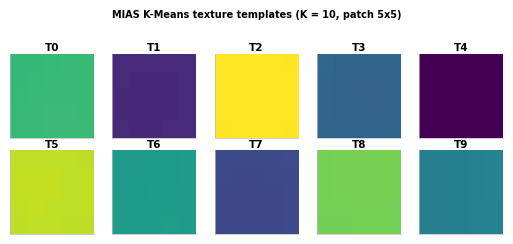

  saved fig19_ddsm_templates.png / .pdf


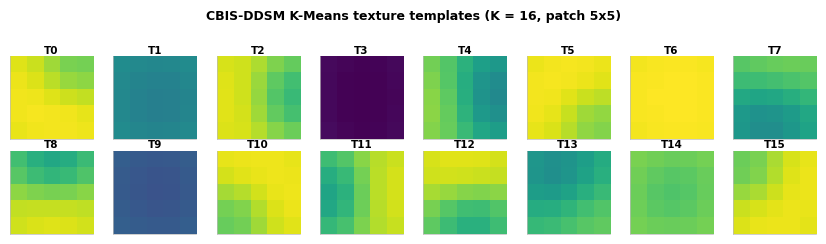

In [17]:
# Figure 18  - MIAS K-Means texture template atlas (K = 10)
# Figure 19 - CBIS-DDSM K-Means texture template atlas (K = 16), below, same cell
def template_atlas(root, title, outname, ncol=8, title_fontsize=10):
    path = os.path.join(root, 'models', 'kmeans_templates.npy')
    if not os.path.exists(path):
        print(f'  skip {outname}: {path} not found'); return
    T = np.load(path)
    K = T.shape[0]
    nrow = int(np.ceil(K / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(1.05 * ncol, 1.18 * nrow))
    axes = np.atleast_1d(axes).ravel()
    vmin, vmax = float(T.min()), float(T.max())
    for i in range(len(axes)):
        ax = axes[i]
        if i < K:
            ax.imshow(T[i], cmap='viridis', vmin=vmin, vmax=vmax)
            ax.set_title(f'T{i}', fontsize=7.5, pad=2.5)
            for s in ax.spines.values():
                s.set_linewidth(0.5); s.set_color('#BBBBBB')
        else:
            ax.axis('off')
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

    fig.suptitle(f'{title} (K = {K}, patch 5x5)', fontsize=title_fontsize,
                 fontweight='semibold', y=1.01)
    fig.tight_layout()
    save(fig, outname)
    plt.show()

if REGENERATE_SAMPLES:
    template_atlas(MIAS_ROOT, 'MIAS K-Means texture templates',
                   'fig18_mias_templates', ncol=5, title_fontsize=7)
    template_atlas(DDSM_ROOT, 'CBIS-DDSM K-Means texture templates',
                   'fig19_ddsm_templates', ncol=8, title_fontsize=9)
else:
    print('Skipped.')

### Note: Figure 22 (CBIS-DDSM crop max-dimension distribution) cannot be regenerated here

This figure plots the **pre-cap** crop sizes (before the 256px resolution cap was applied),
measured from the tightened crop/mask pairs right after loading them from the raw dataset.
That intermediate array (`sizes`) only ever existed in-memory during the original preprocessing
run in `Notebook_1.ipynb` (CBIS-DDSM, Section 3) - only the *post-cap* `roi_h`/`roi_w` columns
were persisted to `preprocessing_metadata.csv`, so this notebook has no source to rebuild it from.

**To include this figure in the report / repo:**
1. Re-run cells 19–21 of the CBIS-DDSM `Notebook_1.ipynb` (a recovery cell can restage the local
   dataset first, since `crop_path`/`mask_path` point to Colab's ephemeral `/content` disk).
2. Add one line at the end of that cell to persist it going forward:
   ```python
   np.save(os.path.join(PREPROCESSED_DIR, "precap_crop_sizes.npy"), sizes)
   ```
3. Until then, use the already-rendered figure saved into `Notebook_1.ipynb`'s saved output
   (cell 21), or the copy already written to `FIGURES_DIR/section4_size_distribution.png` on Drive.